# Generate figures used to explain theory

In the following notebooks, we discuss various concepts relating to the definition of time-explicit unit processes and product systems. In this notebook, we generate figures which facilitate this discussion.

These figures are generated using the data from the previous notebook in combination with the `FunctionalMetabolism` class. Note, however, that this class is virtually entirely vibe coded with large language models. These results are intended solely for the basic illustrative function demonstrated here.

In [1]:
import pandas as pd
import numpy as np
import pickle

import utils
import plotting_class as pc
import plotting_utils as pu
from functional_metabolism import FunctionalMetabolism

In [2]:
with open('dMFA_Results.pkl', 'rb') as f:
    DynFleetResults = pickle.load(f) # deserialize using load()

for k in DynFleetResults:
    print(k, DynFleetResults[k].shape)

I_Veh_cT (91, 2)
S_Veh_tcT (91, 91, 2)
O_Veh_tcT (91, 91, 2)
km_t (91,)
KM_tcT (91, 91, 2)
mj_cT (91, 2)
E_tcT (91, 91, 2)
t (91,)
T (2,)


In [3]:
DynFleetSchema = {
        "time":                 {"key": "t", "dims": ("year",)},
        "technology":           {"key": "T", "dims": ("technology",)},
        "inflow":               {"key": "I_Veh_cT", "dims": ("cohort", "technology",)},
        "stock":                {"key": "S_Veh_tcT", "dims": ("year", "cohort", "technology",)},
        "outflow":              {"key": "O_Veh_tcT", "dims": ("year", "cohort", "technology",)},
        "specific_use":         {"key": "km_t", "dims": ("year",)},
        "fleet_use":            {"key": "KM_tcT", "dims": ("year", "cohort", "technology",)},
        "specific_consumption": {"key": "mj_cT", "dims": ("cohort", "technology",)},
        "fleet_consumption":    {"key": "E_tcT", "dims": ("year", "cohort", "technology",)},
    }

In [4]:
mfa = FunctionalMetabolism(DynFleetResults, DynFleetSchema)

In [5]:
unit_f = 'km'
unit_f_full = f'distance travelled [{unit_f}]'
unit_io = 'items'
unit_io_full = f'number of vehicles [{unit_io}]'
unit_c = 'MJ'
unit_c_full = f'in-use energy consumption [{unit_c}]'

unit_dict = {'use': f'use [{unit_f}]',
             'consumption': f'in-use consumption [{unit_c}]',
             'production': f'production [{unit_io}]',
             'disposal': f'disposal [{unit_io}]',}

main_cols_f = [f'use [{unit_f}]']
main_cols_c = [f'in-use consumption [{unit_c}]']
twin_cols = [f'production [{unit_io}]', f'disposal [{unit_io}]']

kwargs_dict_f = {
    'sci_notation': True,
    'legend_ncol': 1,
    'turn_x_label': False,
    'show_lines': False,
    'show_stem': True,
    'linewidth': 2,
    'markersize': 5,
    'title_loc': 'center',
    'skip_zeroes': True,
    'legend_position': 'lower left',
    'y_label': unit_f_full,
    'twin_y_label': unit_io_full,
    'alpha': 0.6,
    'legend_frameon': True,
    'x_tick_int': True,
}

kwargs_dict_c = {**kwargs_dict_f, 'y_label': unit_c_full}

marker_f = {'marker': 'o',}
marker_c = {'marker': 'H',}
markers_io = {'marker': ['s','D'],}

## Figures to explain the definition of time-explicit unit processes

In [6]:
y_f = 2030
y_i = 2020
y_o = 2040
tech = 'ICEV'
scale_to_local = 100

f_text = f'first-tier demands for driving an {tech} {scale_to_local} {unit_f} in {y_f} according to'
f_text_which = f'first-tier demands for driving {scale_to_local} {unit_f} in {y_f}'

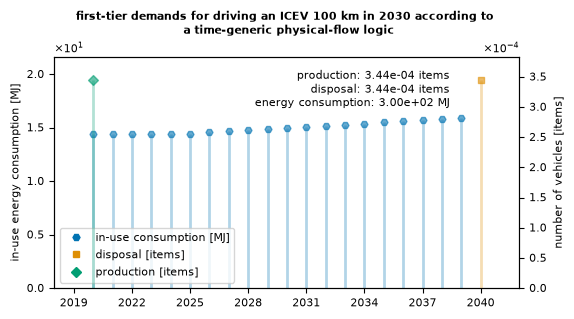

In [7]:
# time-generic physical-flow logic

df = mfa.function_profile(technology=tech, use_year=list(np.arange(y_i,y_o)), inflow_year=y_i, outflow_year=y_o, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.85, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

df_wide = {f'{f_text} \n a time-generic physical-flow logic': utils.aggregate_and_pivot(df, rename_map=unit_dict),}
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_c, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/time_generic_physical_flow')

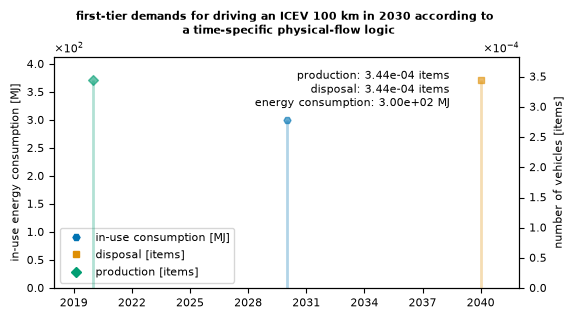

In [8]:
# time-specific physical-flow logic

df = mfa.function_profile(technology=tech, use_year=y_f, inflow_year=y_i, outflow_year=y_o, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.85, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

df_wide = {f'{f_text} \n a time-specific physical-flow logic': utils.aggregate_and_pivot(df, rename_map=unit_dict),}
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_c, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/time_specific_physical_flow')

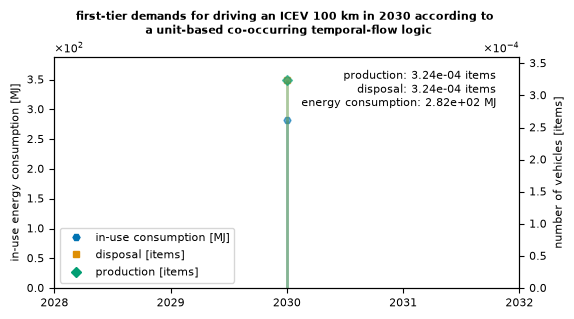

In [9]:
# unit-based co-occurring temporal-flow logic

df = mfa.function_profile(technology=tech, use_year=y_f, inflow_year=y_f, outflow_year=y_f + (y_o-y_i), scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)
df['year'] = y_f

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.95, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

df_wide = {f'{f_text} \n a unit-based co-occurring temporal-flow logic': utils.aggregate_and_pivot(df, rename_map=unit_dict),}
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_c, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/unit_based_co_occurring_temporal_flow')

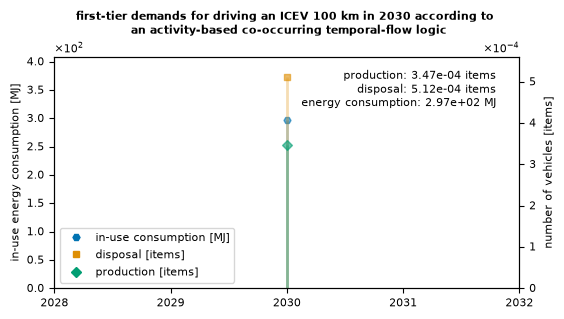

In [10]:
# activity-based co-occurring temporal-flow logic
df = mfa.function_profile(technology=tech, use_year=y_f, include_production_eol=True, include_direct_consumption=True)
total_f = df.loc[df['flow'] == 'use', 'value'].sum()
scaling_factor = scale_to_local / total_f

df_c = df.loc[df['flow'] == 'consumption']
df_c['value'] *= scaling_factor

df_i = mfa.function_profile(technology=tech, use_year=DynFleetResults['t'], inflow_year=y_f, include_production_eol=True, include_direct_consumption=True)
df_i = df_i.loc[df_i['flow'] == 'production']
df_i['value'] *= scaling_factor

df_o = mfa.function_profile(technology=tech, use_year=DynFleetResults['t'], outflow_year=y_f, include_production_eol=True, include_direct_consumption=True)
df_o = df_o.loc[df_o['flow'] == 'disposal']
df_o['value'] *= scaling_factor

df = pd.concat([df_c, df_i, df_o])

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.95, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

df_wide = {f'{f_text} \n an activity-based co-occurring temporal-flow logic': utils.aggregate_and_pivot(df, rename_map=unit_dict),}
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_c, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/activity_based_co_occurring_temporal_flow')

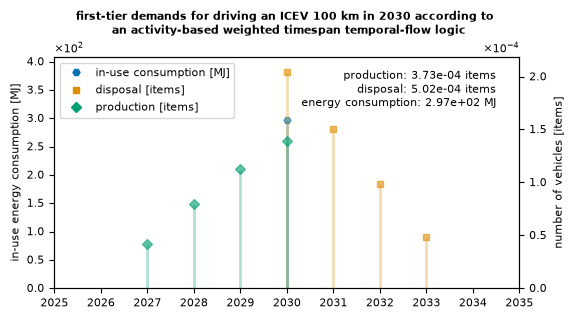

In [11]:
# activity-based weighted timespan temporal-flow logic
weights = [0.4, 0.3, 0.2, 0.1]

df = mfa.function_profile(technology=tech, use_year=y_f, include_production_eol=True, include_direct_consumption=True)
total_f = df.loc[df['flow'] == 'use', 'value'].sum()
scaling_factor = scale_to_local / total_f

df_c = df.loc[df['flow'] == 'consumption']
df_c['value'] *= scaling_factor

df_i = mfa.function_profile(technology=tech, use_year=DynFleetResults['t'], inflow_year=list(np.arange(y_f - len(weights) + 1, y_f + 1)), include_production_eol=True, include_direct_consumption=True)
df_i = df_i.loc[df_i['flow'] == 'production']

df_o = mfa.function_profile(technology=tech, use_year=DynFleetResults['t'], outflow_year=list(np.arange(y_f, y_f + len(weights))), include_production_eol=True, include_direct_consumption=True)
df_o = df_o.loc[df_o['flow'] == 'disposal']

for i in range(len(weights)):
    df_i.loc[df_i['year'] == y_f - i, 'value'] *= scaling_factor * weights[i]
    df_o.loc[df_o['year'] == y_f + i, 'value'] *= scaling_factor * weights[i]

df = pd.concat([df_c, df_i, df_o])

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.95, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['legend_position'] = 'upper left'
df_wide = {f'{f_text} \n an activity-based weighted timespan temporal-flow logic': utils.aggregate_and_pivot(df, rename_map=unit_dict),}
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/activity_based_weighted_timespan_temporal_flow')

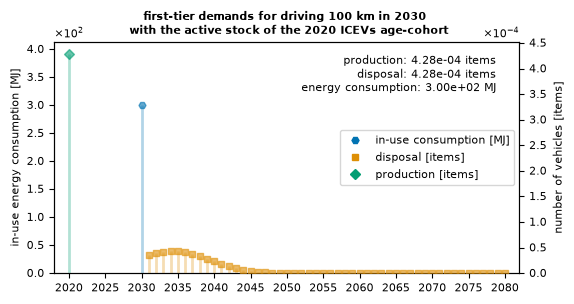

In [12]:
# remaining members of age-cohort
df = mfa.function_profile(technology=tech, use_year=y_f, inflow_year=y_i, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.95, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

df_wide = {f'{f_text_which} \n with the active stock of the {y_i} {tech}s age-cohort': utils.aggregate_and_pivot(df, rename_map=unit_dict),}

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['legend_position'] = 'center right'
kwargs_dict_local['x_tick_mult'] = 5
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/time_specific_physical_flow_cohort')

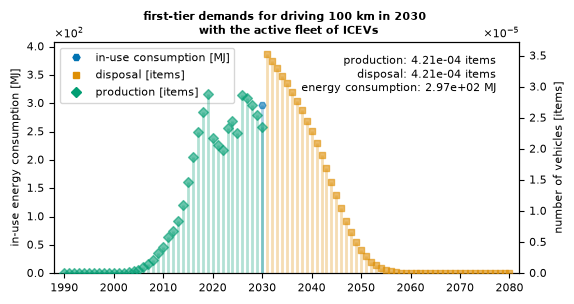

In [13]:
# active fleet
df = mfa.function_profile(technology=tech, use_year=y_f, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.95, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

df_wide = {f'{f_text_which} \n with the active fleet of {tech}s': utils.aggregate_and_pivot(df, rename_map=unit_dict),}

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['legend_position'] = 'upper left'
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])
 
pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/time_specific_physical_flow_fleet_single_tech')

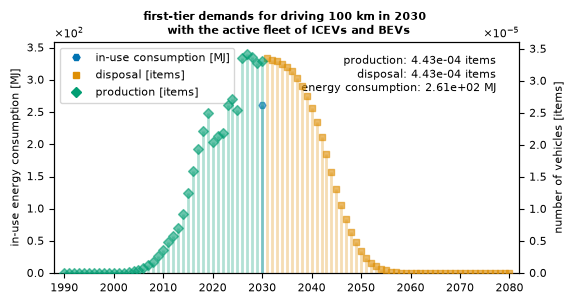

In [14]:
df = mfa.function_profile(use_year=y_f, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

annotation = [{"text": f"production: {df.loc[df['flow'] == 'production', 'value'].sum():.2e} {unit_io}\n disposal: {df.loc[df['flow'] == 'disposal', 'value'].sum():.2e} {unit_io}\n energy consumption: {df.loc[df['flow'] == 'consumption', 'value'].sum():.2e} {unit_c}", 
               "x": 0.95, "y": 0.95, "xycoords": "axes fraction", "ha": "right", "va": "top",
               },]

df_wide = {f'{f_text_which} \n with the active fleet of ICEVs and BEVs': utils.aggregate_and_pivot(df, rename_map=unit_dict),}

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['legend_position'] = 'upper left'
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io, annotations=[annotation])
 
pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/time_specific_physical_flow_fleet')

In [15]:
kwargs_dict_v = {
    'sci_notation': True,
    'title_loc': 'center',
    'keep_y': True,
}

# show active fleet with colours indicating age-cohort (vintage)
# three subplots next to each other, analogue to contributions: production by vintage, consumption by vintage, disposal by vintage
df = mfa.function_profile(technology=tech, use_year=y_f, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

# rows: year at which activity occurs
# columns: vintage ()
df_dict = {
    ('production', unit_io_full): utils.aggregate_and_pivot(df.loc[df['flow'] == 'production'], flow_col="inflow_year"),
    ('consumption', unit_c_full): utils.aggregate_and_pivot(df.loc[df['flow'] == 'consumption'], flow_col="inflow_year"),
    ('disposal', unit_io_full): utils.aggregate_and_pivot(df.loc[df['flow'] == 'disposal'], flow_col="inflow_year"),
}

width_ratios = [d.shape[0] for (key, d) in df_dict.items()]

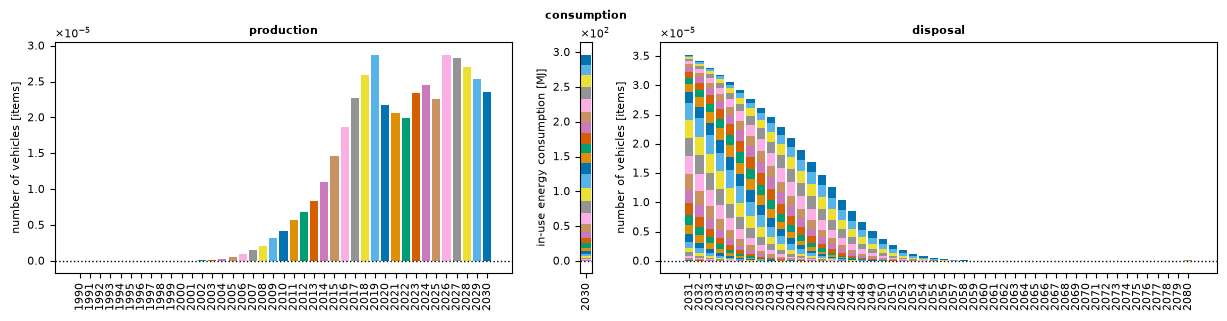

In [16]:
plot_config = pu.construct_plot_config_for_vintage_subplot(df_dict, kwargs_dict_v)

pu.plot_grid(plot_config, ncols=3, figsize=(15,3), sharey=False, sharex=False, add_shared_legend=False, gridspec_kw={'width_ratios': width_ratios}, suptitle=None, wspace=0.2, filepath='./figures/time_specific_physical_flow_fleet_single_tech_by_vintage')

## Figures to explain the definition of time-explicit functional units

In [30]:
lc_text = 'first-tier demands for lifetime use function (distance driven) of'
lc_tech = 'BEV'

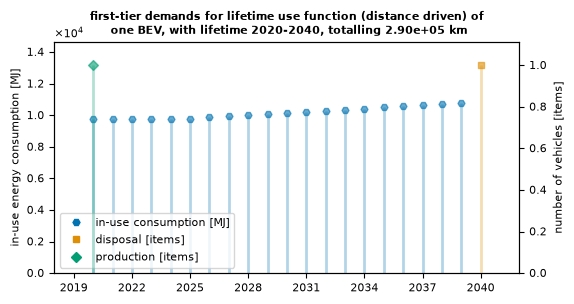

In [31]:
df = mfa.lifetime_profile(inflow_year=y_i, outflow_year=y_o, technology=lc_tech, number_of_objects=1, include_production_eol=True, include_direct_consumption=True)

lifetime_distance = df.loc[df['flow'] == 'use', 'value'].sum()

df_wide = {f'{lc_text}\n one {lc_tech}, with lifetime {y_i}-{y_o}, totalling {lifetime_distance:.2e} {unit_f}': utils.aggregate_and_pivot(df, rename_map=unit_dict),}

plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_c, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io)

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/lifecycle_individual')

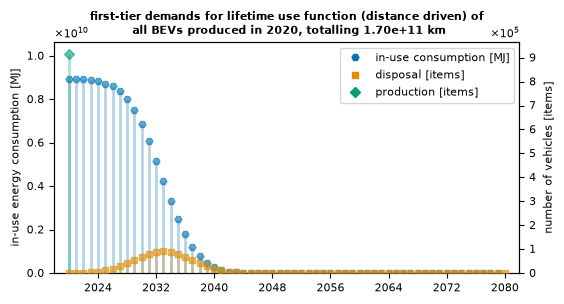

In [32]:
df = mfa.lifetime_profile(inflow_year=y_i, technology=lc_tech, include_production_eol=True, include_direct_consumption=True)

lifetime_distance = df.loc[df['flow'] == 'use', 'value'].sum()

df_wide = {f'{lc_text}\n all {lc_tech}s produced in {y_i}, totalling {lifetime_distance:.2e} {unit_f}': utils.aggregate_and_pivot(df, rename_map=unit_dict),}

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['legend_position'] = 'upper right'
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io)

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/lifecycle_cohort')

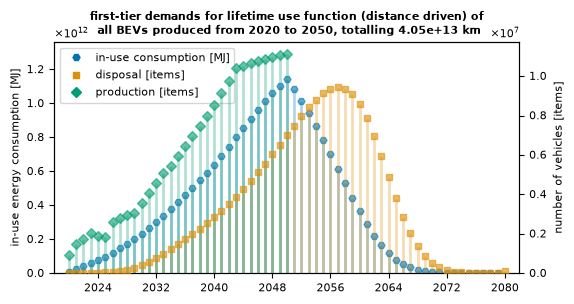

In [42]:
dy_before = 0
dy_after = 30
df = mfa.lifetime_profile(inflow_year=list(np.arange(y_i-dy_before, y_i+dy_after+1)), technology=lc_tech, include_production_eol=True, include_direct_consumption=True)

lifetime_distance = df.loc[df['flow'] == 'use', 'value'].sum()

df_wide = {f'{lc_text}\n all {lc_tech}s produced from {y_i-dy_before} to {y_i+dy_after}, totalling {lifetime_distance:.2e} {unit_f}': utils.aggregate_and_pivot(df, rename_map=unit_dict),}

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['legend_position'] = 'upper left'
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io)

pu.plot_grid(plot_config, ncols=1, figsize=(6,3), sharex=False, suptitle=None, wspace=0.55, hspace=0.3, legend_ax=0, filepath='./figures/lifecycle_cohorts')

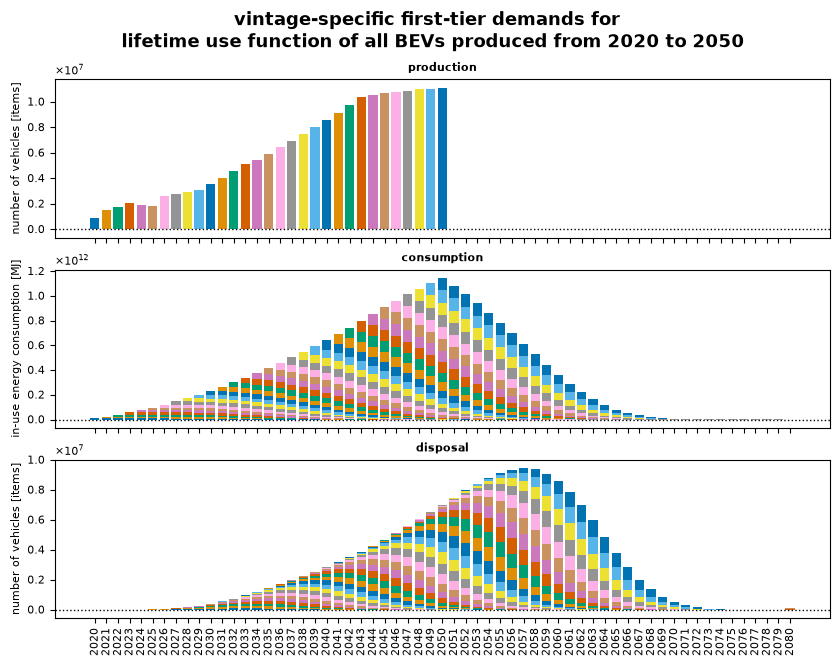

In [57]:
lc_text_vintage = f'vintage-specific first-tier demands for \n lifetime use function of all {lc_tech}s produced from {y_i-dy_before} to {y_i+dy_after}'

df_dict = {
    ('production', unit_io_full): utils.aggregate_and_pivot(df.loc[df['flow'] == 'production'], flow_col="inflow_year"),
    ('consumption', unit_c_full): utils.aggregate_and_pivot(df.loc[df['flow'] == 'consumption'], flow_col="inflow_year"),
    ('disposal', unit_io_full): utils.aggregate_and_pivot(df.loc[df['flow'] == 'disposal'], flow_col="inflow_year"),
}

#width_ratios = [d.shape[0] for (key, d) in df_dict.items()]

plot_config = pu.construct_plot_config_for_vintage_subplot(df_dict, kwargs_dict_v)

pu.plot_grid(plot_config, ncols=1, figsize=(10,7), sharey=False, sharex=True, add_shared_legend=False, suptitle=lc_text_vintage, hspace=0.2, filepath='./figures/lifecycle_cohorts_by_vintage')

## Illustrative panels to demonstrate unit process construction

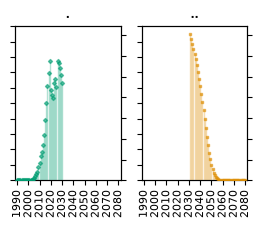

In [34]:
df = mfa.function_profile(technology=tech, use_year=y_f, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

df_production = df.copy()
df_production.loc[df_production['flow'] != 'production', 'value'] *= 0

df_disposal = df.copy()
df_disposal.loc[df_disposal['flow'] != 'disposal', 'value'] *= 0

df_wide = {
    f'.': utils.aggregate_and_pivot(df_production, rename_map=unit_dict),
    f'..': utils.aggregate_and_pivot(df_disposal, rename_map=unit_dict),
    }

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['linewidth'] = 1
kwargs_dict_local['markersize'] = 2
kwargs_dict_local['turn_x_label'] = True
kwargs_dict_local['x_tick_mult'] = 10
kwargs_dict_local['keep_y'] = False
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io)
 
pu.plot_grid(plot_config, ncols=2, figsize=(3,2), add_shared_legend=False, wspace=0.2, legend_ax=0, filepath='./figures/panels_for_configurations1')

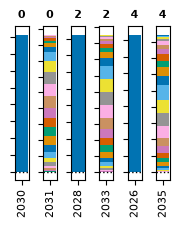

In [35]:
# show all disposal activities in a given year with colours indicating age-cohort (vintage)
# three subplots next to each other, for three years
df_dict = {}
for i in [0,2,4]:
    df = mfa.function_profile(technology=tech, use_year=DynFleetResults['t'], inflow_year=y_f-i, scale_to=scale_to_local, include_production_eol=True)
    df_dict[(f'{i}', 'production')] = utils.aggregate_and_pivot(df.loc[df['flow'] == 'production'], flow_col="inflow_year")
    df = mfa.function_profile(technology=tech, use_year=DynFleetResults['t'], outflow_year=y_f+1+i, scale_to=scale_to_local, include_production_eol=True)
    df_dict[(f'{i}', 'disposal')] = utils.aggregate_and_pivot(df.loc[df['flow'] == 'disposal'], flow_col="inflow_year")

kwargs_dict_local = kwargs_dict_v.copy()
kwargs_dict_local['keep_y'] = False
plot_config = pu.construct_plot_config_for_vintage_subplot(df_dict, kwargs_dict_local)

pu.plot_grid(plot_config, ncols=6, figsize=(2,2), add_shared_legend=False, wspace=1, filepath='./figures/panels_for_configurations2')

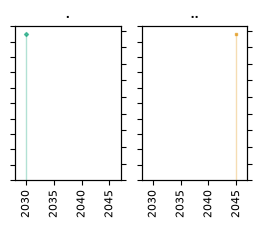

In [36]:
df = mfa.function_profile(technology=tech, use_year=y_f, outflow_year=y_f+15, inflow_year=y_f, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)

df_production = df.copy()
df_production.loc[df_production['flow'] != 'production', 'value'] *= 0

df_disposal = df.copy()
df_disposal.loc[df_disposal['flow'] != 'disposal', 'value'] *= 0

df_wide = {
    f'.': utils.aggregate_and_pivot(df_production, rename_map=unit_dict),
    f'..': utils.aggregate_and_pivot(df_disposal, rename_map=unit_dict),
    }

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['linewidth'] = 1
kwargs_dict_local['markersize'] = 2
kwargs_dict_local['turn_x_label'] = True
kwargs_dict_local['x_tick_mult'] = 5
kwargs_dict_local['keep_y'] = False
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_wide, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io)
 
pu.plot_grid(plot_config, ncols=2, figsize=(3,2), add_shared_legend=False, wspace=0.2, legend_ax=0, filepath='./figures/panels_for_configurations3')

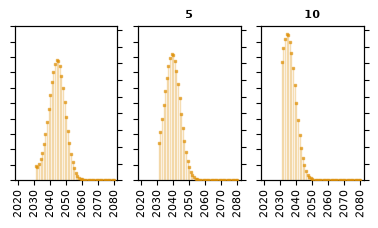

In [37]:
df_dict = {}
for i in [0, 5, 10]:
    df = mfa.function_profile(technology=tech, use_year=y_f, inflow_year=y_f-i, scale_to=scale_to_local, include_production_eol=True, include_direct_consumption=True)
    df.loc[df['flow'] != 'disposal', 'value'] *= 0

    df_dict[i] = utils.aggregate_and_pivot(df, rename_map=unit_dict)

kwargs_dict_local = kwargs_dict_c.copy()
kwargs_dict_local['linewidth'] = 1
kwargs_dict_local['markersize'] = 2
kwargs_dict_local['turn_x_label'] = True
kwargs_dict_local['x_tick_mult'] = 10
kwargs_dict_local['keep_y'] = False
plot_config = pu.construct_plot_config_for_dualaxis_subplot(df_dict, kwargs_dict_local, twin_cols, main_cols_c, share_y_range=True, share_x_range=True, main_kwargs=marker_c, twin_kwargs=markers_io)

pu.plot_grid(plot_config, ncols=3, figsize=(4.5,2), add_shared_legend=False, wspace=0.2, legend_ax=0, filepath='./figures/panels_for_configurations4')